In [218]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [219]:
df = pd.read_csv("historical_data.csv")

In [220]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [221]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     196441 non-null  float64
 1   created_at                                    197428 non-null  str    
 2   actual_delivery_time                          197421 non-null  str    
 3   store_id                                      197428 non-null  int64  
 4   store_primary_category                        192668 non-null  str    
 5   order_protocol                                196433 non-null  float64
 6   total_items                                   197428 non-null  int64  
 7   subtotal                                      197428 non-null  int64  
 8   num_distinct_items                            197428 non-null  int64  
 9   min_item_price                                197428 non-nu

In [222]:
df["created_at"] = pd.to_datetime(df.created_at)
df["actual_delivery_time"] = pd.to_datetime(df["actual_delivery_time"])

In [223]:
#creating the target variable
from datetime import datetime
df["delivery_duration"] = (df["actual_delivery_time"] - df["created_at"]).dt.total_seconds()

In [224]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0,3779.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0,4024.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0,1781.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0,3075.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0,2390.0


In [225]:
df["busy_dasher_ratio"] = (df["total_busy_dashers"] / df["total_onshift_dashers"])

In [226]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration,busy_dasher_ratio
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0,3779.0,0.424242
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0,4024.0,2.000000
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0,1781.0,0.000000
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0,3075.0,1.000000
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0,2390.0,1.000000


In [227]:
df["non_prep_duration"] = (df["estimated_order_place_duration"] + df["estimated_store_to_consumer_driving_duration"])

In [228]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration,busy_dasher_ratio,non_prep_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0,3779.0,0.424242,1307.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0,4024.0,2.000000,1136.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0,1781.0,0.000000,1136.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0,3075.0,1.000000,735.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0,2390.0,1.000000,1096.0


In [229]:
# --- Time-based features ---
df["order_hour"] = df["created_at"].dt.hour
df["order_day_of_week"] = df["created_at"].dt.dayofweek  # 0=Mon, 6=Sun
df["is_weekend"] = df["order_day_of_week"].isin([5, 6]).astype(int)
df["is_rush_hour"] = df["order_hour"].apply(lambda h: 1 if (11 <= h <= 13) or (17 <= h <= 20) else 0)

# --- Dasher pressure features ---
df["orders_per_dasher"] = df["total_outstanding_orders"] / df["total_onshift_dashers"]
df["free_dashers"] = df["total_onshift_dashers"] - df["total_busy_dashers"]

# --- Order size features ---
df["avg_item_price"] = df["subtotal"] / df["total_items"]
df["price_range"] = df["max_item_price"] - df["min_item_price"]

# --- Estimated gap (implied store prep time) ---
df["prep_duration"] = df["delivery_duration"] - df["non_prep_duration"]

df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,...,non_prep_duration,order_hour,order_day_of_week,is_weekend,is_rush_hour,orders_per_dasher,free_dashers,avg_item_price,price_range,prep_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,...,1307.0,22,4,0,0,0.636364,19.0,860.25,682,2472.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,...,1136.0,21,1,0,0,2.000000,-1.0,1900.00,0,2888.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,...,1136.0,20,3,0,1,0.000000,1.0,1900.00,0,645.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,...,735.0,21,1,0,0,2.000000,0.0,1150.00,1200,2340.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,...,1096.0,2,6,1,0,1.500000,0.0,1300.00,500,1294.0


In [230]:
#missing values check 
df.isnull().sum()

market_id                                         987
created_at                                          0
actual_delivery_time                                7
store_id                                            0
store_primary_category                           4760
order_protocol                                    995
total_items                                         0
subtotal                                            0
num_distinct_items                                  0
min_item_price                                      0
max_item_price                                      0
total_onshift_dashers                           16262
total_busy_dashers                              16262
total_outstanding_orders                        16262
estimated_order_place_duration                      0
estimated_store_to_consumer_driving_duration      526
delivery_duration                                   7
busy_dasher_ratio                               19838
non_prep_duration           

In [231]:
df.shape

(197428, 28)

### Step 1 — Data Cleaning

In [232]:
# 1. Drop rows where target variable is missing (only 7 rows)
df = df.dropna(subset=["actual_delivery_time", "delivery_duration"])
print("After dropping missing target rows:", df.shape)

After dropping missing target rows: (197421, 28)


In [233]:
# 2. Impute total_onshift_dashers, total_busy_dashers, total_outstanding_orders
#    group by market_id median, fallback to global median for rows where market_id is null
for col in ["total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders"]:
    df[col] = df.groupby("market_id")[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())  # fallback for null market_id rows

print("Remaining nulls in dasher columns:")
print(df[["total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders"]].isnull().sum())

Remaining nulls in dasher columns:
total_onshift_dashers       0
total_busy_dashers          0
total_outstanding_orders    0
dtype: int64


In [234]:
# 3. Fill categorical nulls with mode (most frequent category)
df["store_primary_category"] = df["store_primary_category"].fillna(df["store_primary_category"].mode()[0])
df["order_protocol"] = df["order_protocol"].fillna(df["order_protocol"].mode()[0])

# 4. Fill estimated_store_to_consumer_driving_duration with market median, fallback to global median
df["estimated_store_to_consumer_driving_duration"] = df.groupby("market_id")["estimated_store_to_consumer_driving_duration"].transform(lambda x: x.fillna(x.median()))
df["estimated_store_to_consumer_driving_duration"] = df["estimated_store_to_consumer_driving_duration"].fillna(df["estimated_store_to_consumer_driving_duration"].median())

# Recompute non_prep_duration after filling its dependency
df["non_prep_duration"] = df["estimated_order_place_duration"] + df["estimated_store_to_consumer_driving_duration"]

In [235]:
# 5. Recompute ratio features now that dasher columns are fully imputed
#    replace 0 in denominator to avoid 0/0 = NaN, then fill with 0
df["busy_dasher_ratio"] = (df["total_busy_dashers"] / df["total_onshift_dashers"].replace(0, np.nan)).fillna(0)
df["orders_per_dasher"] = (df["total_outstanding_orders"] / df["total_onshift_dashers"].replace(0, np.nan)).fillna(0)
df["free_dashers"] = df["total_onshift_dashers"] - df["total_busy_dashers"]

# Recompute prep_duration now that all dependencies are clean
df["prep_duration"] = df["delivery_duration"] - df["non_prep_duration"]

In [236]:
# 5. Final check — confirm no missing values remain
df.isnull().sum()

market_id                                       987
created_at                                        0
actual_delivery_time                              0
store_id                                          0
store_primary_category                            0
order_protocol                                    0
total_items                                       0
subtotal                                          0
num_distinct_items                                0
min_item_price                                    0
max_item_price                                    0
total_onshift_dashers                             0
total_busy_dashers                                0
total_outstanding_orders                          0
estimated_order_place_duration                    0
estimated_store_to_consumer_driving_duration      0
delivery_duration                                 0
busy_dasher_ratio                                 0
non_prep_duration                                 0
order_hour  

In [237]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,...,non_prep_duration,order_hour,order_day_of_week,is_weekend,is_rush_hour,orders_per_dasher,free_dashers,avg_item_price,price_range,prep_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,...,1307.0,22,4,0,0,0.636364,19.0,860.25,682,2472.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,...,1136.0,21,1,0,0,2.000000,-1.0,1900.00,0,2888.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,american,1.0,1,1900,1,1900,...,1136.0,20,3,0,1,0.000000,1.0,1900.00,0,645.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,american,1.0,6,6900,5,600,...,735.0,21,1,0,0,2.000000,0.0,1150.00,1200,2340.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,american,1.0,3,3900,3,1100,...,1096.0,2,6,1,0,1.500000,0.0,1300.00,500,1294.0


### Step 2 - Preparation for model

In [238]:
df["store_id"].nunique()

6743

In [239]:
df["market_id"].nunique()

6

In [240]:
df["store_primary_category"].nunique()

74

In [241]:
df["order_protocol"].nunique()

7

In [242]:
#creating dummies for the order protocol
order_protocol_dummies = pd.get_dummies(df["order_protocol"], dtype=int)
order_protocol_dummies = order_protocol_dummies.add_prefix("order_protocol_")

In [243]:
order_protocol_dummies.head()

,order_protocol_1.0,order_protocol_2.0,order_protocol_3.0,order_protocol_4.0,order_protocol_5.0,order_protocol_6.0,order_protocol_7.0
0,1,0,0,0,0,0,0
1,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0


In [244]:
market_id_dummies = pd.get_dummies(df["market_id"], dtype=int)
market_id_dummies = market_id_dummies.add_prefix("market_id_")
market_id_dummies.head()

,market_id_1.0,market_id_2.0,market_id_3.0,market_id_4.0,market_id_5.0,market_id_6.0
0,1,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,1,0,0,0
3,0,0,1,0,0,0
4,0,0,1,0,0,0


In [245]:
store_primary_category_type = pd.get_dummies(df["store_primary_category"], dtype=int)
store_primary_category_type = store_primary_category_type.add_prefix("category_")
store_primary_category_type.head()

,category_afghan,category_african,category_alcohol,category_alcohol-plus-food,category_american,category_argentine,category_asian,category_barbecue,category_belgian,category_brazilian,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [246]:
# Cyclical encoding for order_hour 
df["hour_sin"] = np.sin(2 * np.pi * df["order_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["order_hour"] / 24)

In [247]:
# Cyclical encoding for DOW
df["day_sin"] = np.sin(2 * np.pi * df["order_day_of_week"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["order_day_of_week"] / 7)

In [248]:
#drop created_at, market_id, store_id, store_primary_category, actual_delivery_time
train_df = df.drop(columns = ["order_protocol","created_at", "market_id", "actual_delivery_time", "store_id", "store_primary_category", "order_hour", "order_day_of_week"])

In [249]:
train_df = pd.concat([train_df, order_protocol_dummies, market_id_dummies, store_primary_category_type], axis=1)

# confirm no duplicate columns
print("Duplicate columns:", train_df.columns[train_df.columns.duplicated()].tolist())
print("Shape:", train_df.shape)

Duplicate columns: []
Shape: (197421, 111)


In [250]:
train_df.head()

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0,...,0,0,0,0,0,0,0,0,0,0
1,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0,...,0,0,0,0,0,0,0,0,0,0
2,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0,...,0,0,0,0,0,0,0,0,0,0
3,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0,...,0,0,0,0,0,0,0,0,0,0
4,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0,...,0,0,0,0,0,0,0,0,0,0


In [251]:
#align dtype over dataset
train_df = train_df.astype("float32")
train_df.head()

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
0,4.0,3441.0,4.0,557.0,1239.0,33.0,14.0,21.0,446.0,861.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1900.0,1.0,1400.0,1400.0,1.0,2.0,2.0,446.0,690.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1900.0,1.0,1900.0,1900.0,1.0,0.0,0.0,446.0,690.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6.0,6900.0,5.0,600.0,1800.0,1.0,1.0,2.0,446.0,289.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,3900.0,3.0,1100.0,1600.0,6.0,6.0,9.0,446.0,650.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [252]:
train_df.describe()

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
count,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,...,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000
mean,3.196367,2682.326416,2.670780,686.224548,1159.590454,43.894726,40.993145,56.533382,308.560242,545.284485,...,0.000790,0.000187,0.005531,0.011078,0.000740,0.036597,0.001200,0.001413,0.004280,0.030873
std,2.666552,1823.106323,1.630261,522.044067,558.416260,33.196133,30.893349,50.645035,90.139725,218.507202,...,0.028099,0.013689,0.074167,0.104667,0.027184,0.187771,0.034627,0.037566,0.065283,0.172974
min,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1400.000000,1.000000,299.000000,800.000000,18.000000,16.000000,18.000000,251.000000,384.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,2200.000000,2.000000,595.000000,1095.000000,36.000000,35.000000,43.000000,251.000000,543.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,3395.000000,3.000000,949.000000,1395.000000,62.000000,59.000000,79.000000,446.000000,701.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2715.000000,2088.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [253]:
train_df["busy_dasher_ratio"].describe()

count    197421.000000
mean          0.933454
std           0.405318
min         -13.000000
25%           0.833333
50%           0.970588
75%           1.000000
max          31.000000
Name: busy_dasher_ratio, dtype: float64

In [254]:
train_df.shape

(197421, 111)

### Step 3 - Correlation check 

In [255]:
# generating a mask for the upper triangle

corr = train_df.corr()

In [256]:
corr

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
total_items,1.000000,0.558061,0.763906,-0.393146,-0.058235,0.031144,0.027926,0.033768,-0.023661,0.004671,...,-0.005924,0.003710,-0.010384,0.057505,0.000582,0.028511,-0.000798,-0.006613,-0.004741,-0.030462
subtotal,0.558061,1.000000,0.681099,0.037041,0.505545,0.127459,0.122170,0.126848,0.039023,0.034654,...,0.005966,0.005319,0.042838,0.057599,0.001592,0.045511,0.003870,-0.003560,-0.002934,-0.041487
num_distinct_items,0.763906,0.681099,1.000000,-0.448738,0.041871,0.063250,0.058024,0.065085,0.003487,0.022640,...,-0.006042,0.004808,-0.005676,0.072729,0.000350,0.066580,0.001887,-0.006215,-0.000705,-0.036723
min_item_price,-0.393146,0.037041,-0.448738,1.000000,0.545485,0.040608,0.042273,0.039151,0.053070,0.003216,...,0.016935,0.002364,0.040694,-0.010719,-0.000708,-0.031728,0.002138,0.005511,-0.003695,-0.012129
max_item_price,-0.058235,0.505545,0.041871,0.545485,1.000000,0.128920,0.126988,0.126479,0.085275,0.026607,...,0.019581,0.004407,0.089458,0.018472,0.001859,-0.008904,0.007912,-0.002826,-0.008127,-0.063061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
category_thai,0.028511,0.045511,0.066580,-0.031728,-0.008904,0.041925,0.043121,0.046982,-0.015346,-0.000945,...,-0.005481,-0.002668,-0.014536,-0.020628,-0.005302,1.000000,-0.006757,-0.007332,-0.012779,-0.034787
category_turkish,-0.000798,0.003870,0.001887,0.002138,0.007912,0.014286,0.012674,0.015385,-0.018024,-0.004561,...,-0.000975,-0.000475,-0.002586,-0.003669,-0.000943,-0.006757,1.000000,-0.001304,-0.002273,-0.006188
category_vegan,-0.006613,-0.003560,-0.006215,0.005511,-0.002826,-0.024613,-0.024652,-0.023146,0.024399,0.003741,...,-0.001058,-0.000515,-0.002806,-0.003982,-0.001023,-0.007332,-0.001304,1.000000,-0.002466,-0.006714
category_vegetarian,-0.004741,-0.002934,-0.000705,-0.003695,-0.008127,0.015765,0.015639,0.015117,-0.014820,0.004137,...,-0.001844,-0.000898,-0.004890,-0.006939,-0.001784,-0.012779,-0.002273,-0.002466,1.000000,-0.011702


In [257]:
mask = np.triu(np.ones_like(corr, dtype=bool))

<Axes: >

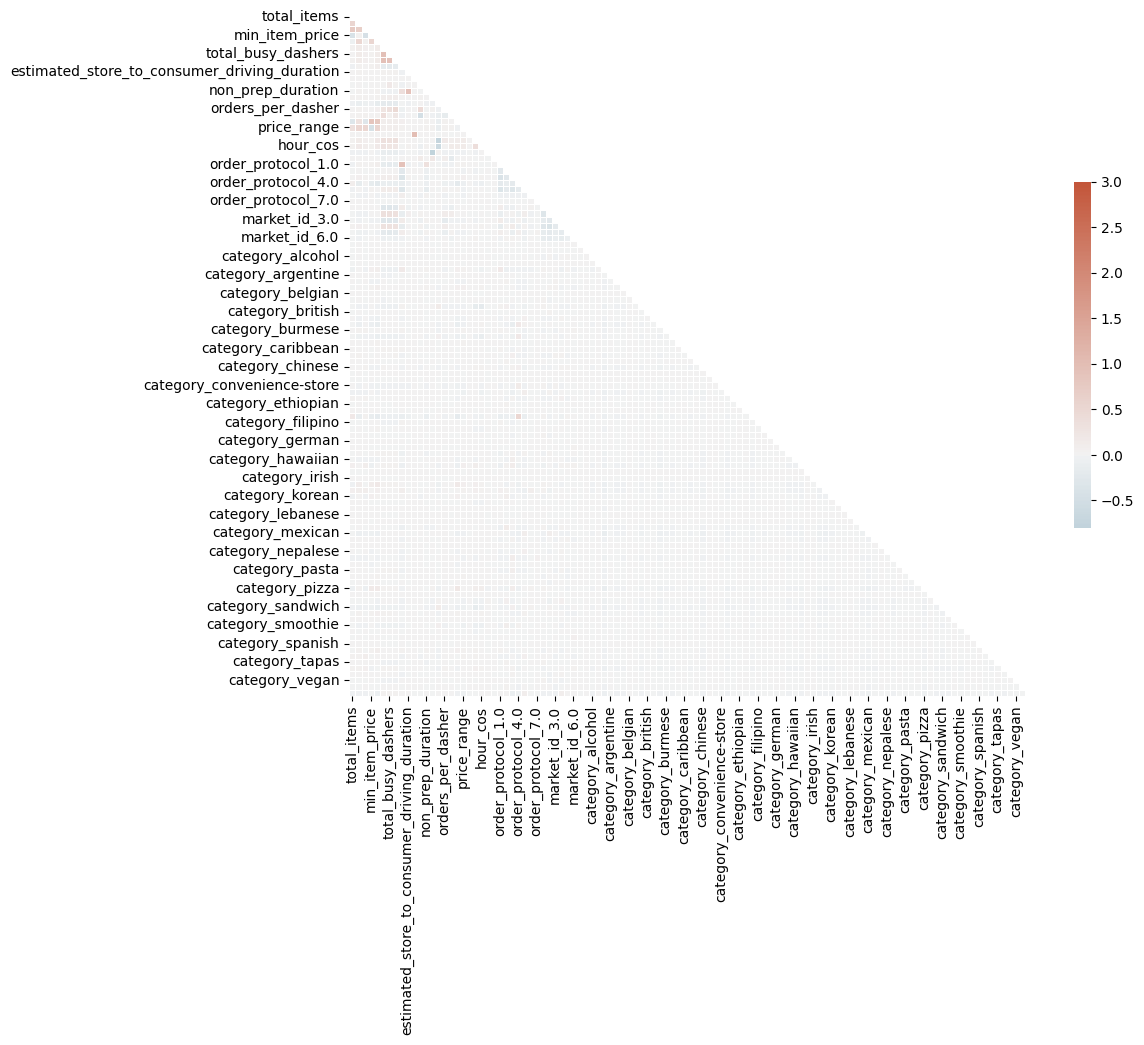

In [258]:
import seaborn as sns
# Setup the matplotlib figure
f ,ax = plt.subplots(figsize=(11,9)) 

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap = True)

#Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask= mask, cmap= cmap, vmax= 3, center= 0, square= True, linewidths= .5, cbar_kws= {"shrink": .5})


In [259]:
def get_redundant_pairs(df):
    """Get pairs of columns to drop from correlation matrix (upper triangle + diagonal)"""
    pairs_to_drop = set()
    cols = df.columns
    for i in range(len(cols)):
        for j in range(i + 1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

In [260]:
def get_top_abs_correlation(train_df, n= 5):
    """Sort the correlation in descending order and return n highrest results"""

    au_corr = train_df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(train_df)
    au_corr =au_corr.drop(labels= labels_to_drop).sort_values(ascending= False)
    return au_corr[0:n]

In [261]:
print("Top Absolute Correlation")
print(get_top_abs_correlation(train_df, 20))

Top Absolute Correlation
delivery_duration                             prep_duration               0.999926
total_onshift_dashers                         total_busy_dashers          0.944365
                                              total_outstanding_orders    0.936884
total_busy_dashers                            total_outstanding_orders    0.933493
estimated_store_to_consumer_driving_duration  non_prep_duration           0.923118
estimated_order_place_duration                order_protocol_1.0          0.890446
min_item_price                                avg_item_price              0.861795
is_weekend                                    day_sin                     0.804175
max_item_price                                avg_item_price              0.771876
total_items                                   num_distinct_items          0.763906
is_rush_hour                                  hour_sin                    0.737389
subtotal                                      num_distinct_ite

In [262]:
#drop highly correlated features 
train_df = train_df.drop(columns = ["total_onshift_dashers", "total_busy_dashers", "prep_duration"])

In [263]:
train_df.shape

(197421, 108)

In [264]:
#align dtype over dataset
train_df = train_df.astype("float32")
train_df.head()

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration,busy_dasher_ratio,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
0,4.0,3441.0,4.0,557.0,1239.0,21.0,446.0,861.0,3779.0,0.424242,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1900.0,1.0,1400.0,1400.0,2.0,446.0,690.0,4024.0,2.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1900.0,1.0,1900.0,1900.0,0.0,446.0,690.0,1781.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6.0,6900.0,5.0,600.0,1800.0,2.0,446.0,289.0,3075.0,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,3900.0,3.0,1100.0,1600.0,9.0,446.0,650.0,2390.0,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [265]:
print("Top Absolute Correlation")
print(get_top_abs_correlation(train_df, 20))

Top Absolute Correlation
estimated_store_to_consumer_driving_duration  non_prep_duration     0.923118
estimated_order_place_duration                order_protocol_1.0    0.890446
min_item_price                                avg_item_price        0.861795
is_weekend                                    day_sin               0.804175
max_item_price                                avg_item_price        0.771876
total_items                                   num_distinct_items    0.763906
is_rush_hour                                  hour_sin              0.737389
subtotal                                      num_distinct_items    0.681099
is_rush_hour                                  hour_cos              0.596552
total_items                                   subtotal              0.558061
min_item_price                                max_item_price        0.545485
max_item_price                                price_range           0.530262
subtotal                                      price

In [266]:
#drop highly correlated features 
train_df = train_df.drop(columns = ["estimated_store_to_consumer_driving_duration", "estimated_order_place_duration"])

In [267]:
train_df.shape

(197421, 106)

In [268]:
print("Top Absolute Correlation")
print(get_top_abs_correlation(train_df, 20))

Top Absolute Correlation
min_item_price            avg_item_price        0.861795
is_weekend                day_sin               0.804175
max_item_price            avg_item_price        0.771876
total_items               num_distinct_items    0.763906
is_rush_hour              hour_sin              0.737389
subtotal                  num_distinct_items    0.681099
is_rush_hour              hour_cos              0.596552
total_items               subtotal              0.558061
min_item_price            max_item_price        0.545485
max_item_price            price_range           0.530262
subtotal                  price_range           0.509565
                          max_item_price        0.505545
order_protocol_4.0        category_fast         0.503391
num_distinct_items        price_range           0.499246
busy_dasher_ratio         free_dashers          0.465084
num_distinct_items        min_item_price        0.448738
total_outstanding_orders  orders_per_dasher     0.444748
busy_d

In [269]:
#new features 
train_df = train_df.drop(columns = ["min_item_price", "max_item_price"])
print("Top Absolute Correlation")
print(get_top_abs_correlation(train_df, 20))

Top Absolute Correlation
is_weekend                day_sin               0.804175
total_items               num_distinct_items    0.763906
is_rush_hour              hour_sin              0.737389
subtotal                  num_distinct_items    0.681099
is_rush_hour              hour_cos              0.596552
total_items               subtotal              0.558061
subtotal                  price_range           0.509565
order_protocol_4.0        category_fast         0.503391
num_distinct_items        price_range           0.499246
busy_dasher_ratio         free_dashers          0.465084
total_outstanding_orders  orders_per_dasher     0.444748
busy_dasher_ratio         orders_per_dasher     0.435963
order_protocol_1.0        order_protocol_3.0    0.380832
hour_sin                  hour_cos              0.366943
market_id_2.0             market_id_4.0         0.350505
order_protocol_1.0        order_protocol_5.0    0.337228
total_outstanding_orders  hour_sin              0.335532
total_

In [270]:
train_df = train_df.drop(columns = ["day_sin", "total_items"])
print("Top Absolute Correlation")
print(get_top_abs_correlation(train_df, 20))

Top Absolute Correlation
is_rush_hour              hour_sin              0.737389
subtotal                  num_distinct_items    0.681099
is_rush_hour              hour_cos              0.596552
subtotal                  price_range           0.509565
order_protocol_4.0        category_fast         0.503391
num_distinct_items        price_range           0.499246
busy_dasher_ratio         free_dashers          0.465084
total_outstanding_orders  orders_per_dasher     0.444748
busy_dasher_ratio         orders_per_dasher     0.435963
order_protocol_1.0        order_protocol_3.0    0.380832
hour_sin                  hour_cos              0.366943
market_id_2.0             market_id_4.0         0.350505
order_protocol_1.0        order_protocol_5.0    0.337228
total_outstanding_orders  hour_sin              0.335532
order_protocol_3.0        order_protocol_5.0    0.326618
non_prep_duration         order_protocol_1.0    0.321425
total_outstanding_orders  market_id_2.0         0.310618
market

In [271]:
train_df = train_df.drop(columns = ["hour_sin", "num_distinct_items"])
print("Top Absolute Correlation")
print(get_top_abs_correlation(train_df, 20))

Top Absolute Correlation
is_rush_hour              hour_cos              0.596552
subtotal                  price_range           0.509565
order_protocol_4.0        category_fast         0.503391
busy_dasher_ratio         free_dashers          0.465084
total_outstanding_orders  orders_per_dasher     0.444748
busy_dasher_ratio         orders_per_dasher     0.435963
order_protocol_1.0        order_protocol_3.0    0.380832
market_id_2.0             market_id_4.0         0.350505
order_protocol_1.0        order_protocol_5.0    0.337228
order_protocol_3.0        order_protocol_5.0    0.326618
non_prep_duration         order_protocol_1.0    0.321425
total_outstanding_orders  market_id_2.0         0.310618
market_id_1.0             market_id_2.0         0.303792
total_outstanding_orders  market_id_4.0         0.285800
subtotal                  avg_item_price        0.284647
market_id_1.0             market_id_4.0         0.275347
total_outstanding_orders  market_id_3.0         0.269171
      

In [272]:
train_df.shape

(197421, 100)

In [273]:
train_df = train_df.drop(columns = ["hour_cos"])
print("Top Absolute Correlation")
print(get_top_abs_correlation(train_df, 20))

Top Absolute Correlation
subtotal                  price_range           0.509565
order_protocol_4.0        category_fast         0.503391
busy_dasher_ratio         free_dashers          0.465084
total_outstanding_orders  orders_per_dasher     0.444748
busy_dasher_ratio         orders_per_dasher     0.435963
order_protocol_1.0        order_protocol_3.0    0.380832
market_id_2.0             market_id_4.0         0.350505
order_protocol_1.0        order_protocol_5.0    0.337228
order_protocol_3.0        order_protocol_5.0    0.326618
non_prep_duration         order_protocol_1.0    0.321425
total_outstanding_orders  market_id_2.0         0.310618
market_id_1.0             market_id_2.0         0.303792
total_outstanding_orders  market_id_4.0         0.285800
subtotal                  avg_item_price        0.284647
market_id_1.0             market_id_4.0         0.275347
total_outstanding_orders  market_id_3.0         0.269171
                          market_id_1.0         0.254095
order_